In [48]:
import os
import operator
from typing import Literal
from typing_extensions import TypedDict, Annotated
from pydantic import BaseModel, Field
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langgraph.graph import StateGraph, START, END

load_dotenv()

llm = ChatOpenAI(model="gpt-5.4-mini", temperature=0)


In [49]:
MANDATE = {
    "umrn": "UMRN7721904",
    "account": "SB-441908",
    "creditor": "Horizon Bank Home Loans",
    "loan_id": "HL-2291",
    "pull_amount": 18450,
    "narration_on_statement": "NACH DR",
    "value_date": "2026-10-02",
}

LOAN = {
    "loan_id": "HL-2291",
    "emi": 15200,
    "pre_emi_interest": 3250,
    "why_extra": "Interest for the days between last month's loan payout and the first EMI date.",
    "screen_status": "unpaid",
    "screen_note": "The loan screen stays unpaid until the NACH return file confirms the debit did not bounce.",
}

CASE = {"return_file_published": False}

In [50]:
def lookup_mandate():
    return dict(MANDATE)


def check_return_file(umrn):
    if not CASE["return_file_published"]:
        return {
            "umrn": umrn,
            "return_file": "not_ready",
            "bounced": None,
            "note": "End-of-day return file is not published yet. A bounce is still possible.",
        }
    return {
        "umrn": umrn,
        "return_file": "ready",
        "bounced": False,
        "note": "Return file is in. This debit is present and did not bounce.",
    }


In [51]:
class State(TypedDict):
    messages: Annotated[list, operator.add]
    next: str

def transcript(state):
    return "\n\n".join(m.content for m in state["messages"])

In [52]:
SERVICE_PROMPT = """You are the service desk at Horizon Bank.
You read the customer's message and choose the next desk. You do not look up mandates or loans.

Colleagues you may call:
- nach_desk: the description is a NACH pull (the words NACH or NACH DR). A NACH pull is money the customer already allowed someone to take. It is not a stolen-card charge and not a UPI payment.
- home_loan: only when an earlier note already names a home-loan id. The customer will not name it. Do not guess the product from the amount.
- FINISH: only when an earlier note is already a finished customer reply. Never on the first message.

The words "someone has taken my money" describe how the customer feels. They do not choose the desk.
If the description says NACH, next is nach_desk.
"""


In [53]:
NACH_PROMPT = """You are the NACH desk. FACTS is the mandate and the return-file check you just ran.
You do not explain loan math. You do not write the customer reply.

Colleagues you may call:
- home_loan: FACTS names a home-loan id. Tell them the loan id, the amount, and whether the return file is ready. Also call home_loan after you have re-checked the return file for them.
- service_desk: only if FACTS cannot identify the creditor.
- FINISH: do not use it on this case.

Rules:
- If no home_loan note exists yet, next is home_loan.
- If the latest home_loan note asked you to check the return file, report these FACTS and set next to home_loan again.
- Do not split 18450 into EMI and interest. That is the loan team's job.
"""

In [54]:
LOAN_PROMPT = """You are the home-loan team. LOAN is the only loan record you may use.
Earlier notes from nach_desk tell you the pull amount and the return-file status. Use the LATEST nach_desk note.

Colleagues you may call:
- nach_desk: you need the return file checked, or the latest note says it is not ready. Do not tell the customer the amount is final while a bounce is still possible.
- FINISH:  when the latest nach_desk note says the return file is ready and bounced is false. 
 or if return file is not ready , respond saying that bounce may still happen
reason must then be a plain reply of 3 or 4 sentences: the EMI, the extra interest, why both were pulled together,
 and that the debit did not bounce or may bounce

Rules:
- 18450 must equal emi plus pre_emi_interest. Use the numbers in LOAN. Do not invent fees.
- screen_status unpaid is not proof the customer was not charged. The screen waits for the return file.
- If the return file is not_ready, or no nach_desk note says bounced is false, next is nach_desk, not FINISH.
"""

In [55]:
def service_desk(state: State):

    class ServiceHandoff(BaseModel):
        reason: str = Field(description="One sentence: what you read, and why this colleague is next.")
        next: Literal["nach_desk", "home_loan", "FINISH"]

    prompt = ChatPromptTemplate.from_messages([
        ("system", SERVICE_PROMPT),
        MessagesPlaceholder("messages"),
        ("human", "{packet}"),
    ])

    chain = prompt | llm.with_structured_output(ServiceHandoff)

    decision= chain.invoke({
        "messages": state["messages"],
        "packet": "Choose the next desk from the customer message only.",
    })

   
    note = f"service_desk: {decision.reason}"
    print(note)
    return {"messages": [HumanMessage(content=note, name="service_desk")], "next": decision.next}

In [56]:
def nach_desk(state: State):
    mandate = lookup_mandate()
    return_file = check_return_file(mandate["umrn"])
    packet = f"FACTS\nMandate: {mandate}\nReturn file: {return_file}"


    class NachHandoff(BaseModel):
        reason: str = Field(description="One sentence: the UMRN finding, and why this colleague is next.")
        next: Literal["home_loan", "service_desk", "FINISH"]

    prompt = ChatPromptTemplate.from_messages([
        ("system", NACH_PROMPT),
        MessagesPlaceholder("messages"),
        ("human", "{packet}"),
    ])

    chain = prompt | llm.with_structured_output(NachHandoff)

    decision = chain.invoke({
        "messages": state["messages"],
        "packet": packet,
    })

   
    note = f"nach_desk: {decision.reason}"
    print(note)
    return {"messages": [HumanMessage(content=note, name="nach_desk")], "next": decision.next}


    


In [57]:
def home_loan(state: State):
     packet = f"LOAN\n{LOAN}"

     prompt = ChatPromptTemplate.from_messages([
        ("system", LOAN_PROMPT),
        MessagesPlaceholder("messages"),
        ("human", "{packet}"),
    ])

     class LoanHandoff(BaseModel):
        reason: str = Field(description="One sentence: the loan id, the amount, and why this colleague is next.")
        next: Literal["nach_desk", "FINISH"]
     chain = prompt | llm.with_structured_output(LoanHandoff)

     decision = chain.invoke({
        "messages": state["messages"],
        "packet": packet,
     })

   
     note = f"home_loan: {decision.reason}"
     print(note)
     return {"messages": [HumanMessage(content=note, name="home_loan")], "next": decision.next}
     
     
    

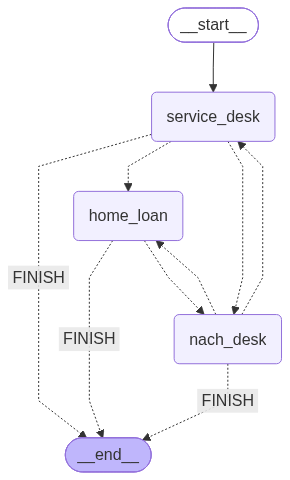

In [58]:
workflow = StateGraph(State)
workflow.add_node("service_desk", service_desk)
workflow.add_node("nach_desk", nach_desk)
workflow.add_node("home_loan", home_loan)

workflow.set_entry_point("service_desk")
workflow.add_conditional_edges("service_desk", lambda state: state['next'],
    {
        "nach_desk": "nach_desk",
        "home_loan": "home_loan",
        "FINISH": END,
    }
)

workflow.add_conditional_edges("nach_desk", lambda state: state['next'],
    {
        "home_loan": "home_loan",
        "service_desk": "service_desk",
        "FINISH": END,
    }
)

workflow.add_conditional_edges("home_loan", lambda state: state['next'],
    {
        "nach_desk": "nach_desk",
        "FINISH": END,
    }
)

graph = workflow.compile()
graph

In [59]:
result = graph.invoke(
    {
        "messages": [
            HumanMessage(content="₹18,450 left my savings account yesterday. The description only says NACH DR. I never approved a payment. I think someone has taken my money", name="customer"),
        ],
    }
)
result


service_desk: I read that the description says NACH DR, which makes this a NACH pull, so the next desk is nach_desk.
nach_desk: UMRN7721904 maps to Horizon Bank Home Loans / loan HL-2291 for ₹18,450, and the return file is not ready yet, so home_loan is next.
home_loan: Loan HL-2291 has a NACH debit of ₹18,450, made up of ₹15,200 EMI and ₹3,250 pre-EMI interest; the return file is not ready yet, so a bounce may still happen and nach_desk is next.
nach_desk: UMRN7721904 maps to Horizon Bank Home Loans / loan HL-2291 for ₹18,450, and the return file is still not ready, so home_loan is next.
home_loan: Loan HL-2291 has a NACH debit of ₹18,450 made up of ₹15,200 EMI and ₹3,250 pre-EMI interest, and the latest nach_desk note says the return file is still not ready so a bounce may still happen.
nach_desk: UMRN UMRN7721904 maps to Horizon Bank Home Loans / loan HL-2291 for ₹18,450, and the return file is still not ready so home_loan is next.
home_loan: Loan HL-2291 had a NACH debit of ₹18,450

KeyboardInterrupt: 